# BMW Global Sales Analysis - Section A  


## Analysis Objective

This section aims to answer three questions:

1. Did BEV share increase clearly across all regions from 2018 to 2025?
2. Which region showed the strongest transition toward electrification?
3. Was higher BEV share associated with units sold and revenue?

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Preparation
### 1.1 Load Data

In [25]:
# Load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf


file_path = '/content/drive/MyDrive/bmw/bmw_global_sales_2018_2025.csv'
df = pd.read_csv(file_path)


print(df.head())
print(df.shape)
print(df.columns)
print(df.dtypes)

   Year  Month  Region     Model  Units_Sold  Avg_Price_EUR  Revenue_EUR  \
0  2018      1  Europe  3 Series        7822          47482    371404204   
1  2018      1  Europe  5 Series       10280          61685    634121800   
2  2018      1  Europe        X3        3105          58433    181434465   
3  2018      1  Europe        X5        7420          67955    504226100   
4  2018      1  Europe        X7        8474          92300    782150200   

   BEV_Share  Premium_Share  GDP_Growth  Fuel_Price_Index  
0      0.011          19.12         3.5               1.0  
1      0.019          19.12         3.5               1.0  
2      0.022          19.12         3.5               1.0  
3      0.021          19.12         3.5               1.0  
4      0.035          19.12         3.5               1.0  
(3072, 11)
Index(['Year', 'Month', 'Region', 'Model', 'Units_Sold', 'Avg_Price_EUR',
       'Revenue_EUR', 'BEV_Share', 'Premium_Share', 'GDP_Growth',
       'Fuel_Price_Index'],
    


### 1.2 Initial data quality check

Before starting the analysis, the dataset is checked for duplicate rows and missing values.
This helps identify any obvious data quality issues that may affect later calculations.

In [27]:
# data quality checks

print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values in each column:")
print(df.isna().sum())

Duplicate rows: 0

Missing values in each column:
Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64


### 1.3 Clean invalid BEV share values

Since `BEV_Share` is a ratio, it should lie between 0 and 1.
Any negative values or values greater than 1 are treated as invalid and replaced with missing values (`NaN`).

In [28]:
# Clean invalid BEV share values

df_clean = df.copy()

# BEV_Share should be between 0 and 1
invalid_bev_mask = (df_clean["BEV_Share"] < 0) | (df_clean["BEV_Share"] > 1)
invalid_bev_count = invalid_bev_mask.sum()
invalid_bev_ratio = invalid_bev_count / len(df_clean)

print("BEV share cleaning")
print("Total rows:", len(df_clean))
print("Invalid BEV_Share rows:", invalid_bev_count)
print("Invalid BEV_Share ratio:", round(invalid_bev_ratio, 5))

print("\ninvalid BEV_Share values:")
print(
    df_clean.loc[
        invalid_bev_mask,
        ["Year", "Month", "Region", "Model", "Units_Sold", "Revenue_EUR", "BEV_Share"]
    ].head(10)
)

# Replace invalid values with NaN
df_clean.loc[invalid_bev_mask, "BEV_Share"] = np.nan
print("\nMissing BEV_Share after cleaning:", df_clean["BEV_Share"].isna().sum())

BEV share cleaning
Total rows: 3072
Invalid BEV_Share rows: 9
Invalid BEV_Share ratio: 0.00293

invalid BEV_Share values:
     Year  Month       Region Model  Units_Sold  Revenue_EUR  BEV_Share
158  2018      5  RestOfWorld    iX        8853    675032397     -0.001
174  2018      6        China    iX        8223    606610710     -0.015
186  2018      6  RestOfWorld    X3        4846    285405170     -0.002
212  2018      7          USA    X7        5923    548440185     -0.005
223  2018      7  RestOfWorld  MINI        8111    338009703     -0.001
238  2018      8        China    iX        6192    468276192     -0.003
275  2018      9          USA    X5        8505    588214305     -0.007
292  2018     10       Europe    X7        3590    333823330     -0.001
356  2018     12       Europe    X7       10765    997721730     -0.002

Missing BEV_Share after cleaning: 9


### 1.4 Create a monthly date column

A proper monthly date column is created from `Year` and `Month` to support time-based aggregation and visualization.

In [29]:
# Create a monthly date column
df_clean["Date"] = pd.to_datetime(
    dict(year=df_clean["Year"], month=df_clean["Month"], day=1)
)

print(df_clean[["Year", "Month", "Date"]].head())

   Year  Month       Date
0  2018      1 2018-01-01
1  2018      1 2018-01-01
2  2018      1 2018-01-01
3  2018      1 2018-01-01
4  2018      1 2018-01-01


### 1.5 Check macro-variable consistency
The consistency check helps confirm that taking the first value of `GDP_Growth` and `Fuel_Price_Index` within each region-month group is reasonable.

In [30]:
# Check whether macro variables are consistent

macro_check = (
    df_clean.groupby(["Year", "Month", "Region"], as_index=False)
    .agg(
        GDP_unique=("GDP_Growth", "nunique"),
        Fuel_unique=("Fuel_Price_Index", "nunique")
    )
)

print("Macro variable consistency check")
print("Maximum unique GDP_Growth values within one region-month group:", macro_check["GDP_unique"].max())
print("Maximum unique Fuel_Price_Index values within one region-month group:", macro_check["Fuel_unique"].max())

Macro variable consistency check
Maximum unique GDP_Growth values within one region-month group: 1
Maximum unique Fuel_Price_Index values within one region-month group: 1


### 1.6 Prepare weighted BEV components

`BEV_Share` is a proportion rather than a count, so it cannot be added directly across rows.

To build a region-level BEV measure, a weighted approach is used:


 `Valid_Units_for_BEV`: units sold from rows with a valid `BEV_Share`

`Weighted_BEV_Share`: `BEV_Share × Units_Sold`


In [31]:
# Prepare weighted BEV

# Keep sales volume only for rows where BEV_Share is valid
df_clean["Valid_Units_for_BEV"] = np.where(
    df_clean["BEV_Share"].notna(),
    df_clean["Units_Sold"],
    0
)

# Weighted BEV contribution = BEV_Share × Units_Sold
df_clean["Weighted_BEV_Share"] = np.where(
    df_clean["BEV_Share"].notna(),
    df_clean["BEV_Share"] * df_clean["Units_Sold"],
    0
)

### 1.7 Build the region-month dataset

In [32]:
# Build the region-month dataset

region_monthly = (
    df_clean.groupby(["Date", "Year", "Month", "Region"], as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue_EUR=("Revenue_EUR", "sum"),
        Valid_Units_for_BEV=("Valid_Units_for_BEV", "sum"),
        Weighted_BEV_Share=("Weighted_BEV_Share", "sum"),
        GDP_Growth=("GDP_Growth", "first"),
        Fuel_Price_Index=("Fuel_Price_Index", "first")
    )
)

# Calculate weighted BEV share
region_monthly["BEV_Share"] = np.where(
    region_monthly["Valid_Units_for_BEV"] > 0,
    region_monthly["Weighted_BEV_Share"] / region_monthly["Valid_Units_for_BEV"],
    np.nan
)

# Calculate average price
region_monthly["Avg_Price_EUR"] = np.where(
    region_monthly["Units_Sold"] > 0,
    region_monthly["Revenue_EUR"] / region_monthly["Units_Sold"],
    np.nan
)

print("Region-month dataset shape:")
display(region_monthly.head())

Region-month dataset shape:


,Date,Year,Month,Region,Units_Sold,Revenue_EUR,Valid_Units_for_BEV,Weighted_BEV_Share,GDP_Growth,Fuel_Price_Index,BEV_Share,Avg_Price_EUR
0,2018-01-01,2018,1,China,54742,3565766365,54742,928.696,2.37,1.02,0.016965,65137.670619
1,2018-01-01,2018,1,Europe,55067,3618339188,55067,1283.409,3.50,1.00,0.023306,65707.941017
2,2018-01-01,2018,1,RestOfWorld,61600,3845115765,61600,739.177,4.18,0.97,0.012000,62420.710471
3,2018-01-01,2018,1,USA,58786,3802037615,58786,878.442,0.82,0.97,0.014943,64675.902681
4,2018-02-01,2018,2,China,39572,2545481878,39572,1069.514,2.66,0.98,0.027027,64325.327959


### 1.8 Build the region-year dataset



In [42]:
# Build the region-year dataset


region_yearly = (
    region_monthly.groupby(["Year", "Region"], as_index=False)
    .agg(
        Units_Sold=("Units_Sold", "sum"),
        Revenue_EUR=("Revenue_EUR", "sum"),
        Valid_Units_for_BEV=("Valid_Units_for_BEV", "sum"),
        Weighted_BEV_Share=("Weighted_BEV_Share", "sum")
    )
)

region_yearly["BEV_Share"] = np.where(
    region_yearly["Valid_Units_for_BEV"] > 0,
    region_yearly["Weighted_BEV_Share"] / region_yearly["Valid_Units_for_BEV"],
    np.nan
)

region_yearly["Avg_Price_EUR"] = np.where(
    region_yearly["Units_Sold"] > 0,
    region_yearly["Revenue_EUR"] / region_yearly["Units_Sold"],
    np.nan
)

print("Region-year dataset shape:")

display(region_yearly.head())

Region-year dataset shape:


,Year,Region,Units_Sold,Revenue_EUR,Valid_Units_for_BEV,Weighted_BEV_Share,BEV_Share,Avg_Price_EUR
0,2018,China,675593,43906098288,661178,13677.922,0.020687,64988.977518
1,2018,Europe,706759,45228201998,692404,14840.263,0.021433,63993.811183
2,2018,RestOfWorld,699539,44656431893,677729,13828.145,0.020404,63836.943892
3,2018,USA,683302,42984486220,668874,14372.333,0.021487,62907.010692
4,2019,China,705400,45538083738,705400,30398.383,0.043094,64556.398835


## 2. BEV Transition Analysis
### 2.1 Yearly BEV share by region



In [43]:
# Create a pivot table for yearly BEV share
yearly_bev_table = region_yearly.pivot(index="Year", columns="Region", values="BEV_Share")

print("Yearly BEV share by region")
display(yearly_bev_table.round(4))

Yearly BEV share by region


Region,China,Europe,RestOfWorld,USA
Year,,,,
2018,0.0207,0.0214,0.0204,0.0215
2019,0.0431,0.0452,0.0457,0.0437
2020,0.0698,0.0690,0.0713,0.0713
2021,0.0942,0.0955,0.0966,0.0938
2022,0.1201,0.1204,0.1191,0.1198
2023,0.1444,0.1443,0.1459,0.1467
2024,0.1697,0.1718,0.1720,0.1693
2025,0.1943,0.1949,0.1933,0.1942


### 2.2 Heatmap of yearly BEV share

The following heatmap shows how BEV share evolved across regions between 2018 and 2025.

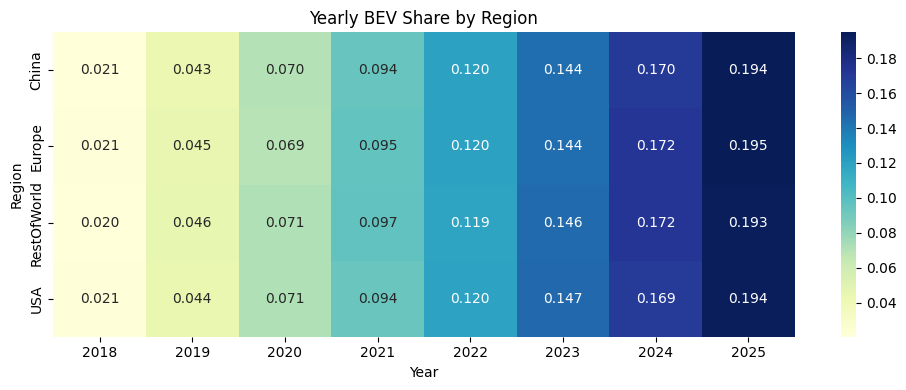

In [35]:
# Plot yearly BEV share
heatmap_data = region_yearly.pivot(index="Region", columns="Year", values="BEV_Share")

plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Yearly BEV Share by Region")
plt.xlabel("Year")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

### 2.3 Measure transition strength

To compare transition strength more directly, two indicators are calculated for each region:

`End_Start_Change`: the increase in BEV share from 2018 to 2025

`Slope_per_Year`: the average yearly rate of increase over the full period

In [44]:
# Measure transition strength
transition_records = []

for region, group in region_yearly.groupby("Region"):
    group = group.sort_values("Year").reset_index(drop=True)

    bev_2018_series = group.loc[group["Year"] == 2018, "BEV_Share"]
    bev_2025_series = group.loc[group["Year"] == 2025, "BEV_Share"]

    # Skip the region if either year is missing
    if len(bev_2018_series) == 0 or len(bev_2025_series) == 0:
        continue

    bev_2018 = bev_2018_series.iloc[0]
    bev_2025 = bev_2025_series.iloc[0]

    valid_group = group.dropna(subset=["BEV_Share"]).copy()

    # A slope needs at least two valid points
    if len(valid_group) >= 2:
        slope = np.polyfit(valid_group["Year"], valid_group["BEV_Share"], 1)[0]
    else:
        slope = np.nan

    transition_records.append({
        "Region": region,
        "BEV_2018": bev_2018,
        "BEV_2025": bev_2025,
        "End_Start_Change": bev_2025 - bev_2018,
        "Slope_per_Year": slope
    })

transition_table = pd.DataFrame(transition_records)

print("Electrification transition summary")
display(transition_table.round(6))

Electrification transition summary


,Region,BEV_2018,BEV_2025,End_Start_Change,Slope_per_Year
0,China,0.020687,0.194273,0.173586,0.024976
1,Europe,0.021433,0.194912,0.173479,0.024979
2,RestOfWorld,0.020404,0.193272,0.172868,0.024853
3,USA,0.021487,0.194227,0.172740,0.024873


### 2.4 Regional increase in BEV share

The following figure compares the total increase in BEV share between 2018 and 2025.

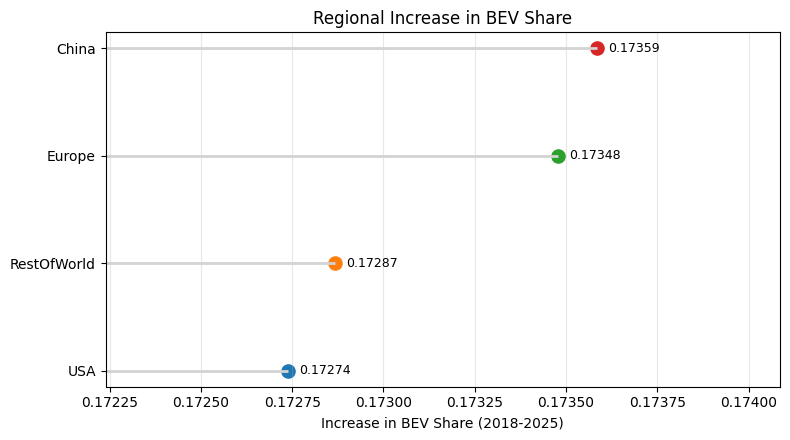

In [37]:
# Plot regional increase in BEV share
increase_plot = transition_table.sort_values("End_Start_Change", ascending=True).reset_index(drop=True)

xmin = increase_plot["End_Start_Change"].min() - 0.0005
xmax = increase_plot["End_Start_Change"].max() + 0.0005

plt.figure(figsize=(8, 4.5))

for i, row in increase_plot.iterrows():
    plt.hlines(y=i, xmin=xmin, xmax=row["End_Start_Change"], color="lightgray", linewidth=2)
    plt.scatter(row["End_Start_Change"], i, s=90)
    plt.text(
        row["End_Start_Change"] + 0.00003,
        i,
        f"{row['End_Start_Change']:.5f}",
        va="center",
        fontsize=9
    )

plt.yticks(range(len(increase_plot)), increase_plot["Region"])
plt.xlim(xmin, xmax)
plt.xlabel("Increase in BEV Share (2018-2025)")
plt.title("Regional Increase in BEV Share")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 2.5 Annual BEV transition slope by region



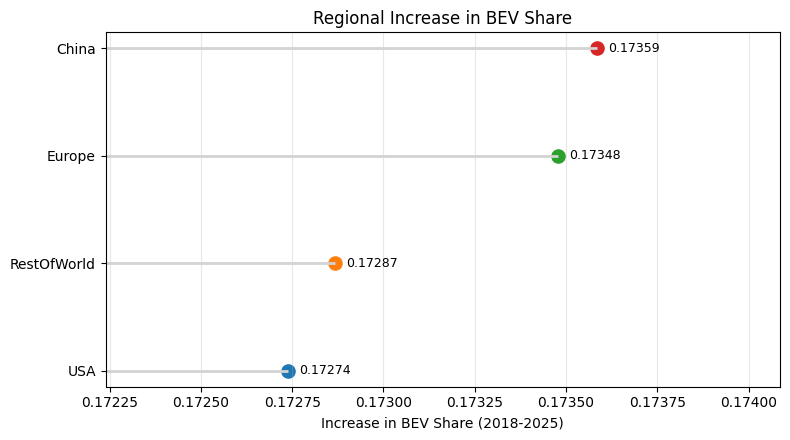

In [38]:
# Plot regional increase in BEV share
increase_plot = transition_table.sort_values("End_Start_Change", ascending=True).reset_index(drop=True)

xmin = increase_plot["End_Start_Change"].min() - 0.0005
xmax = increase_plot["End_Start_Change"].max() + 0.0005

plt.figure(figsize=(8, 4.5))

for i, row in increase_plot.iterrows():
    plt.hlines(y=i, xmin=xmin, xmax=row["End_Start_Change"], color="lightgray", linewidth=2)
    plt.scatter(row["End_Start_Change"], i, s=90)
    plt.text(
        row["End_Start_Change"] + 0.00003,
        i,
        f"{row['End_Start_Change']:.5f}",
        va="center",
        fontsize=9
    )

plt.yticks(range(len(increase_plot)), increase_plot["Region"])
plt.xlim(xmin, xmax)
plt.xlabel("Increase in BEV Share (2018-2025)")
plt.title("Regional Increase in BEV Share")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 2.6 Yearly regional gap check
The yearly maximum gaps are small, confirming that regional differences in BEV share remained modest throughout the period.
This helps explain why some visualizations show highly similar patterns across regions..

In [45]:
# Check yearly gap across regions
region_gap_by_year = region_yearly.pivot(index="Year", columns="Region", values="BEV_Share")

region_gap_by_year["max_gap"] = (
    region_gap_by_year.max(axis=1) - region_gap_by_year.min(axis=1)
)

print("Yearly regional gap in BEV share")
display(region_gap_by_year.round(6))

Yearly regional gap in BEV share


Region,China,Europe,RestOfWorld,USA,max_gap
Year,,,,,
2018,0.020687,0.021433,0.020404,0.021487,0.001084
2019,0.043094,0.045191,0.045717,0.043698,0.002624
2020,0.069752,0.068954,0.071310,0.071285,0.002356
2021,0.094151,0.095472,0.096599,0.093803,0.002796
2022,0.120057,0.120356,0.119133,0.119760,0.001223
2023,0.144388,0.144275,0.145858,0.146661,0.002386
2024,0.169701,0.171800,0.171991,0.169319,0.002672
2025,0.194273,0.194912,0.193272,0.194227,0.001640


## 3. Correlation between BEV share, units sold, and revenue



In [46]:
# Calculate the correlation between BEV share, units sold, and revenue by region
correlation_records = []

for region, group in region_monthly.groupby("Region"):
    temp = group.dropna(subset=["BEV_Share"]).copy()

    correlation_records.append({
        "Region": region,
        "Corr_BEV_vs_Units": temp["BEV_Share"].corr(temp["Units_Sold"]),
        "Corr_BEV_vs_Revenue": temp["BEV_Share"].corr(temp["Revenue_EUR"])
    })

correlation_table = pd.DataFrame(correlation_records).sort_values("Region").reset_index(drop=True)

print("Correlation summary by region")
display(correlation_table.round(4))

Correlation summary by region


,Region,Corr_BEV_vs_Units,Corr_BEV_vs_Revenue
0,China,0.4430,0.4315
1,Europe,0.3778,0.3728
2,RestOfWorld,0.2379,0.2589
3,USA,0.4895,0.4715


In [41]:
print("Final transition table")
display(transition_table.round(6))

print("Final correlation table")
display(correlation_table.round(4))

Final transition table


,Region,BEV_2018,BEV_2025,End_Start_Change,Slope_per_Year
0,China,0.020687,0.194273,0.173586,0.024976
1,Europe,0.021433,0.194912,0.173479,0.024979
2,RestOfWorld,0.020404,0.193272,0.172868,0.024853
3,USA,0.021487,0.194227,0.172740,0.024873


Final correlation table


,Region,Corr_BEV_vs_Units,Corr_BEV_vs_Revenue
0,China,0.4430,0.4315
1,Europe,0.3778,0.3728
2,RestOfWorld,0.2379,0.2589
3,USA,0.4895,0.4715


## 4. Conclusion

Three main conclusions can be drawn from this section:

1. BEV share increased steadily in all regions from 2018 to 2025.
2. China and Europe were marginally ahead in terms of transition strength, but regional differences were small overall.
3. The electrification transition appears to be broad-based rather than concentrated in one strongly dominant region.